# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [2]:
aviation_df = pd.read_csv("Aviation_Cleaned.csv")

aviation_df.shape

/var/folders/y_/8lgqgn_17j53v04m52jxzw7c0000gn/T/ipykernel_73772/4074824726.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  aviation_df = pd.read_csv("Aviation_Cleaned.csv")


(18115, 32)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [ ]:
aviation_df["Aircraft.Size"] = aviation_df["Number.of.Passengers"] >= 20
aviation_df["Aircraft.Size"] = aviation_df["Aircraft.Size"].replace([True, False], ["Large", "Small"])

small_df = aviation_df[aviation_df["Aircraft.Size"] == "Small"]
large_df = aviation_df[aviation_df["Aircraft.Size"] == "Large"]

print(len(small_df))
print(len(large_df))

print(f"The dataset contains {len(small_df)} small airplanes and {len(large_df)} large airplanes")

17229
886


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

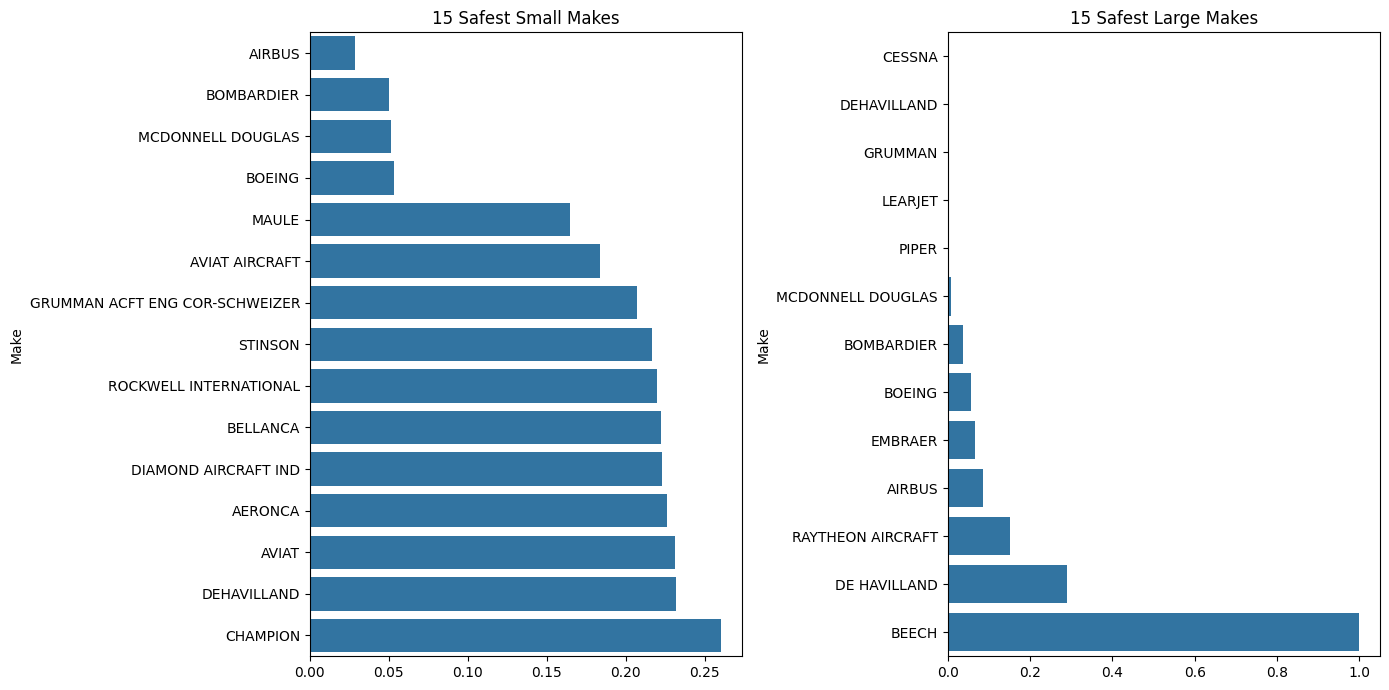

In [4]:
small_means = small_df.loc[:, ["Make", "Severity.Likelihood"]].groupby("Make")["Severity.Likelihood"].mean().nsmallest(15)

large_means = large_df.loc[:, ["Make", "Severity.Likelihood"]].groupby("Make")["Severity.Likelihood"].mean().nsmallest(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

barplot1 = sns.barplot(x=small_means.values, y=small_means.index, ax=ax1)
barplot1.set(title="15 Safest Small Makes")

barplot2 = sns.barplot(x=large_means.values, y=large_means.index, ax=ax2)
barplot2.set(title="15 Safest Large Makes")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

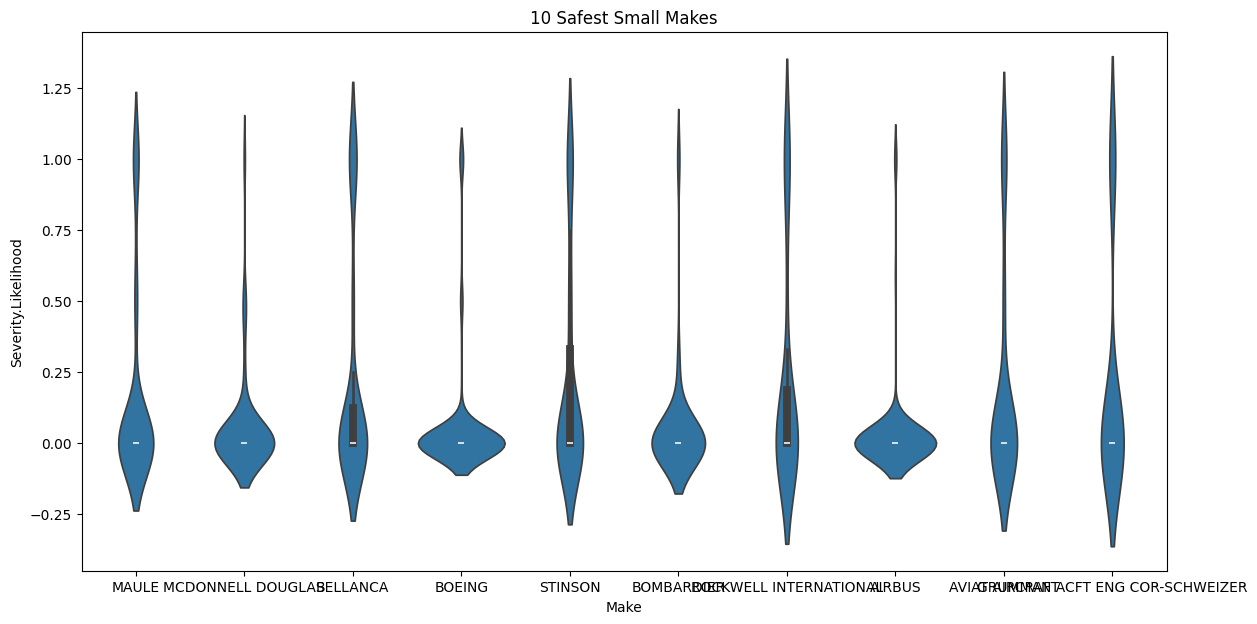

In [5]:
filtered_makes = small_means.nsmallest(10).index

filtered_df = small_df[small_df["Make"].isin(filtered_makes)]

fig, ax = plt.subplots(figsize=(14, 7))

sns.violinplot(data=filtered_df, x="Make", y="Severity.Likelihood")
ax.set(title="10 Safest Small Makes")

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

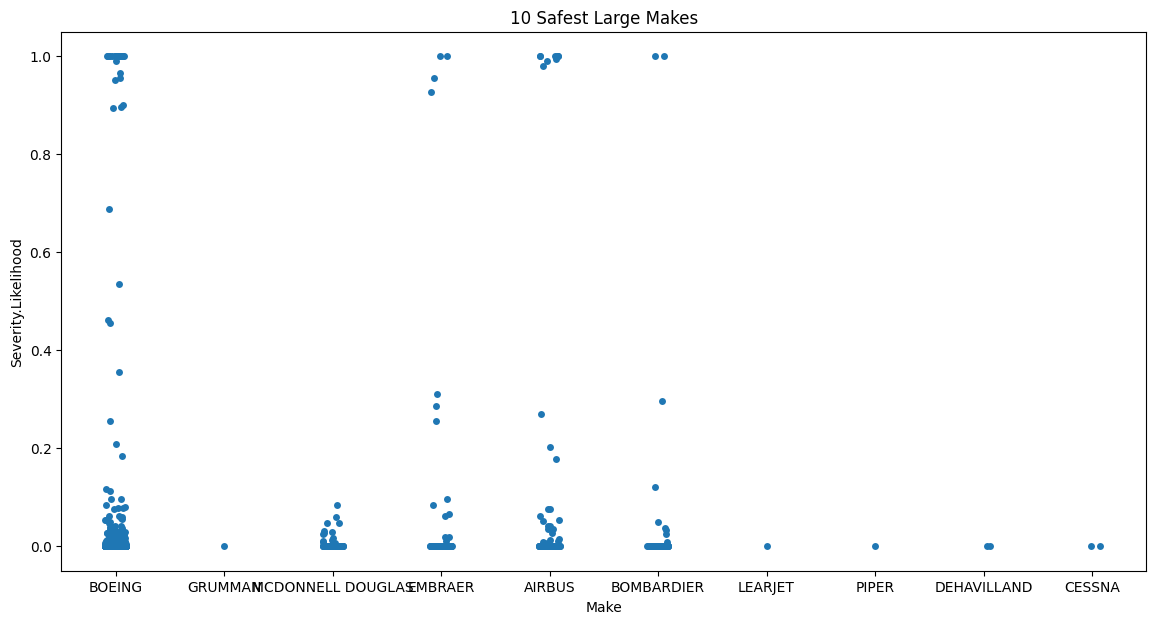

In [6]:
filtered_makes = large_means.nsmallest(10).index

filtered_df = large_df[large_df["Make"].isin(filtered_makes)]

fig, ax = plt.subplots(figsize=(14, 7))

sns.stripplot(data=filtered_df, x="Make", y="Severity.Likelihood")
ax.set(title="10 Safest Large Makes")

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

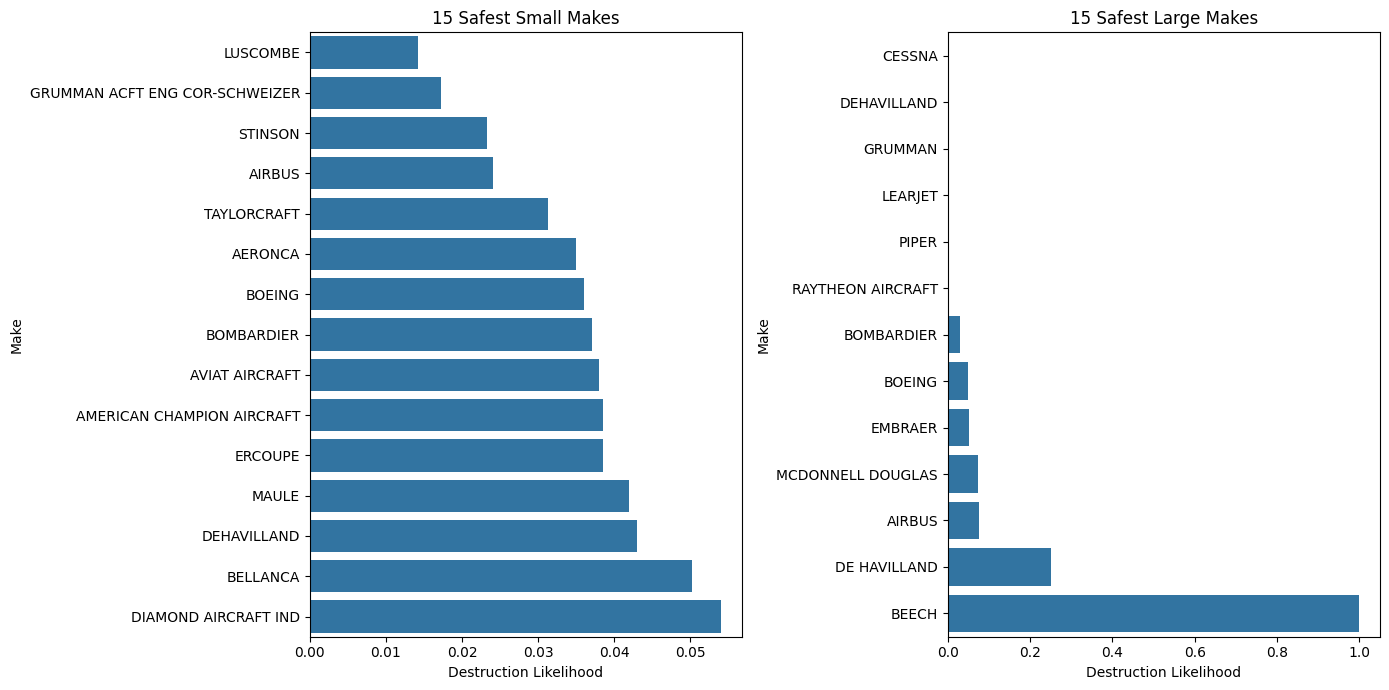

In [7]:
small_destruction_means = small_df.groupby("Make")["Aircraft.Destroyed"].mean().nsmallest(15)
large_destruction_means = large_df.groupby("Make")["Aircraft.Destroyed"].mean().nsmallest(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

barplot3 = sns.barplot(x=small_destruction_means.values, y=small_destruction_means.index, ax=ax1)
barplot3.set(title="15 Safest Small Makes",xlabel="Destruction Likelihood")

barplot4 = sns.barplot(x=large_destruction_means.values, y=large_destruction_means.index, ax=ax2)
barplot4.set(title="15 Safest Large Makes",xlabel="Destruction Likelihood")

plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

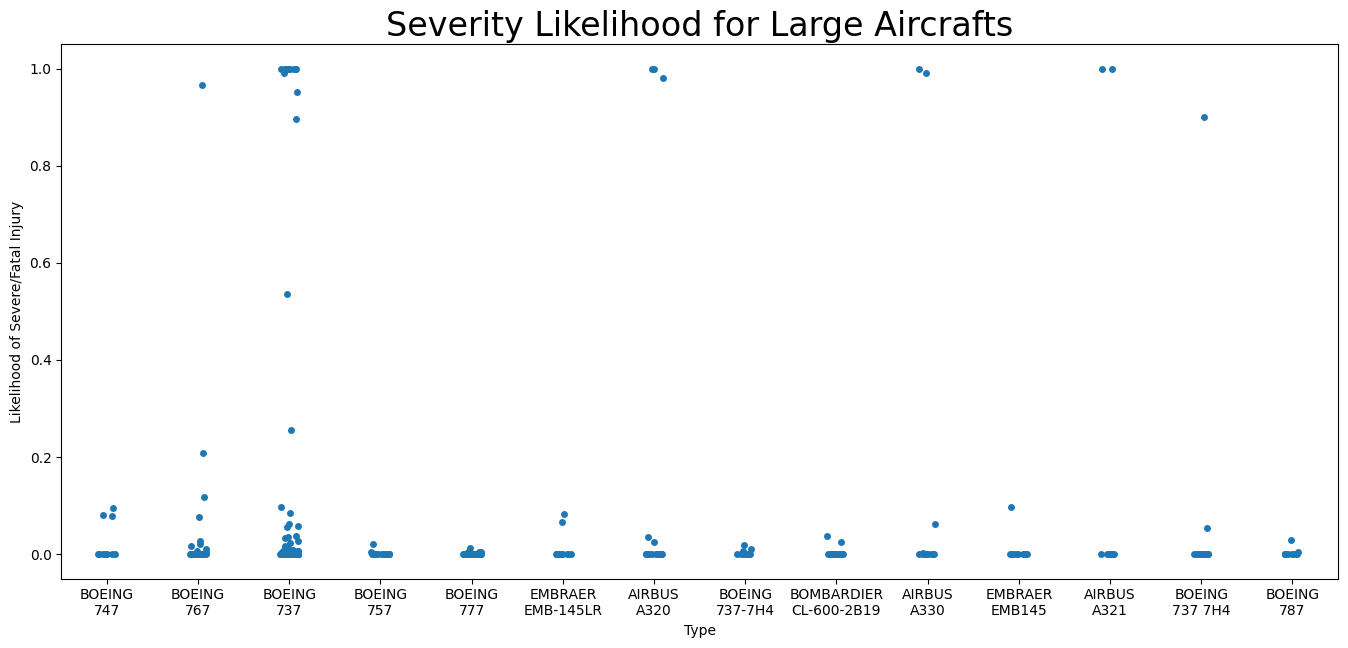

In [ ]:
large_type_counts = large_df["Aircraft.Type"].value_counts()
filtered_df = large_df[large_df["Aircraft.Type"].map(large_type_counts) >= 10]

fig, ax = plt.subplots(figsize=(14, 7))

sns.set_context('poster')
sns.stripplot(data=filtered_df, x="Aircraft.Type", y="Severity.Likelihood")
ax.set(title="Severity Likelihood for Large Aircrafts", xlabel="Type", ylabel="Likelihood of Severe/Fatal Injury")

# Use newline to separate Model and Make on x-axis ticks
locs, labels = plt.xticks()
new_labels = [label.get_text().replace(' ', '\n', 1) for label in labels]
plt.xticks(locs, new_labels)

plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

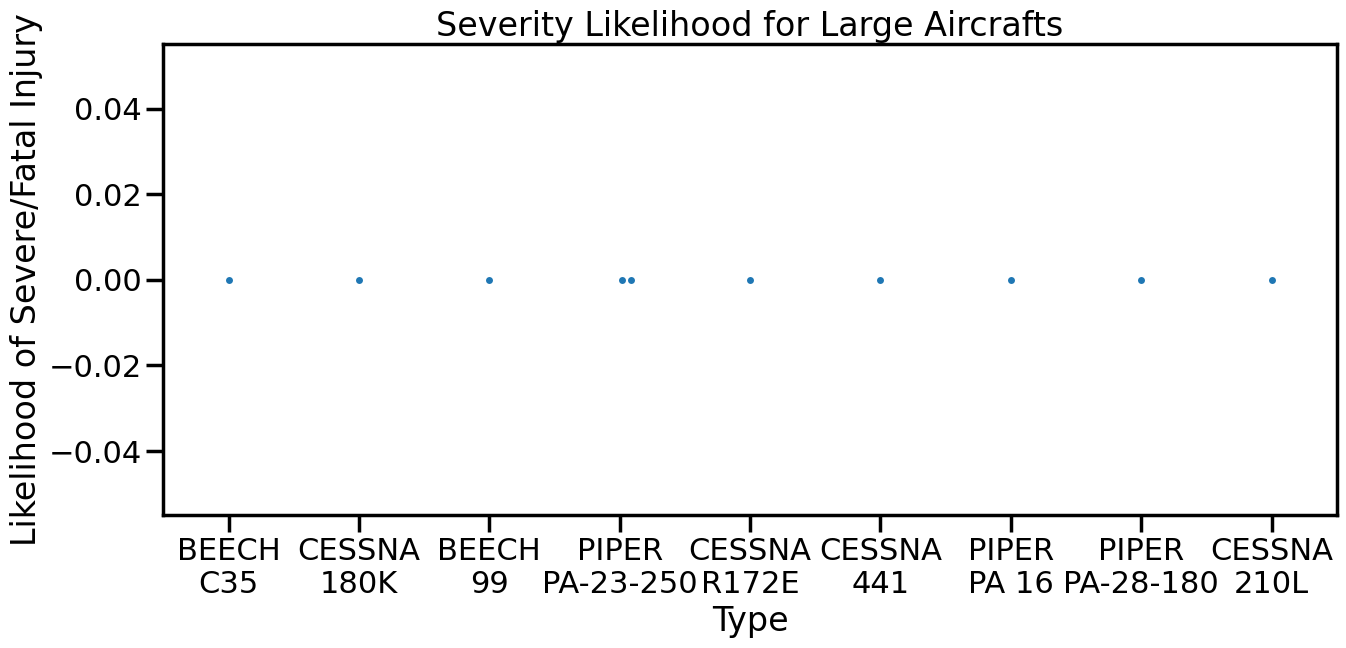

In [16]:
small_type_counts = small_df["Aircraft.Type"].value_counts()
filtered_df = small_df[small_df["Aircraft.Type"].map(small_type_counts) >= 10].nsmallest(10, "Severity.Likelihood")


fig, ax = plt.subplots(figsize=(14, 7))

sns.set_context('poster')
sns.stripplot(data=filtered_df, x="Aircraft.Type", y="Severity.Likelihood")
ax.set(title="Severity Likelihood for Large Aircrafts", xlabel="Type", ylabel="Likelihood of Severe/Fatal Injury")

# Use newline to separate Model and Make on x-axis ticks
locs, labels = plt.xticks()
new_labels = [label.get_text().replace(' ', '\n', 1) for label in labels]
plt.xticks(locs, new_labels)

plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.